In [3]:
!pip install h5py

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.5/19.5 MB 117.5 MB/s eta 0:00:00


In [ ]:
### VISUALIZE THE H5 FILE WE WILL USE ###

In [104]:
import h5py

def list_contents(h5_file):
    with h5py.File(h5_file, 'r') as file:
        print("Listing all groups and datasets within the file:")
        file.visititems(print_name_and_info)

def print_name_and_info(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(f"Dataset: {name} - Shape: {obj.shape}, Dtype: {obj.dtype}")
    else:
        print(f"Group: {name}")

def check_data_in_h5(file_path):
    with h5py.File(file_path, 'r') as f:
        for name in f:
            print(name, f[name]['true_vol'][:].sum())  # Check if the volume contains non-zero values

def view_dataset(h5_file, dataset_path):
    with h5py.File(h5_file, 'r') as file:
        if dataset_path in file:
            data = file[dataset_path][()]
            print(f"Data from {dataset_path}:")
            print(data)
        else:
            print(f"Dataset {dataset_path} not found in file.")

h5_file = '20250713_cryo_data_backbone.h5'
#check_data_in_h5('cryo_data.h5')

# List all groups and datasets
list_contents(h5_file)

# View specific dataset (replace 'group/dataset' with actual path in your H5 file)
view_dataset(h5_file, 'group/dataset')


Listing all groups and datasets within the file:
Group: EMDB_10018
Dataset: EMDB_10018/em_volume_real - Shape: (64, 64, 64), Dtype: float32
Dataset: EMDB_10018/em_volume_synthetic - Shape: (64, 64, 64), Dtype: float32
Dataset: EMDB_10018/ground_truth_coords - Shape: (1290, 3), Dtype: float32
Dataset: EMDB_10018/ground_truth_grid - Shape: (64, 64, 64), Dtype: float32
Dataset: EMDB_10018/homolog_complex - Shape: (64, 64, 64), Dtype: float32
Dataset: EMDB_10018/homolog_perturbed1 - Shape: (64, 64, 64), Dtype: float32
Dataset: EMDB_10018/homolog_perturbed2 - Shape: (64, 64, 64), Dtype: float32
Dataset: EMDB_10018/scale_min - Shape: (3,), Dtype: float32
Dataset: EMDB_10018/scale_norm - Shape: (), Dtype: float32
Group: EMDB_10036
Dataset: EMDB_10036/em_volume_real - Shape: (64, 64, 64), Dtype: float32
Dataset: EMDB_10036/em_volume_synthetic - Shape: (64, 64, 64), Dtype: float32
Dataset: EMDB_10036/ground_truth_coords - Shape: (11805, 3), Dtype: float32
Dataset: EMDB_10036/ground_truth_grid -

In [106]:
import torch
from torch.utils.data import Dataset
import h5py
import importlib
import CryoData
importlib.reload(CryoData)
from CryoData import CryoDataBackbone, CryoDataAllAtom

# Usage example
dataset = CryoDataBackbone('20250713_cryo_data_backbone.h5')
allatom_dataset = CryoDataAllAtom('20250713_cryo_data_allAtom.h5')

# Assuming you have a CryoData instance called 'dataset'
# Print all the keys in the dataset
for i in range(3):  # Check the first three samples
    sample = dataset[i]
    print(f'Emdb ID: {sample["emdb_id"]}')
    print(f'Keys: {sample.keys()}')
    print(f'Homolog Data: {sample["syn_density"].shape}')
    print()


Emdb ID: 10018
Keys: dict_keys(['emdb_id', 'pdb_id', 'representation', 'gt_voxel', 'gt_coords', 'em_density', 'syn_density', 'scale_norm', 'scale_min', 'homolog_1', 'homolog_2', 'homolog_3'])
Homolog Data: torch.Size([64, 64, 64])

Emdb ID: 10036
Keys: dict_keys(['emdb_id', 'pdb_id', 'representation', 'gt_voxel', 'gt_coords', 'em_density', 'syn_density', 'scale_norm', 'scale_min', 'homolog_1', 'homolog_2', 'homolog_3'])
Homolog Data: torch.Size([64, 64, 64])

Emdb ID: 10088
Keys: dict_keys(['emdb_id', 'pdb_id', 'representation', 'gt_voxel', 'gt_coords', 'em_density', 'syn_density', 'scale_norm', 'scale_min', 'homolog_1', 'homolog_2', 'homolog_3'])
Homolog Data: torch.Size([64, 64, 64])



In [107]:
import torch
from torch.utils.data import DataLoader, random_split

dataset_size = len(dataset)
train_size = int(0.95 * dataset_size)  # 80% for training
test_size = dataset_size - train_size  # 20% for testing

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Data loaders for both train and test sets
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# Length of the train loader
print(len(train_loader))
print(len(test_loader))

225
12


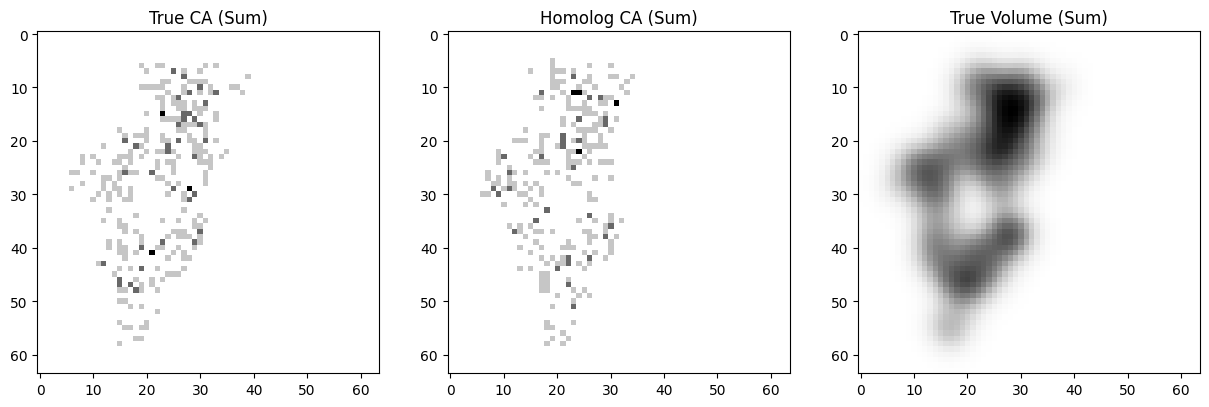

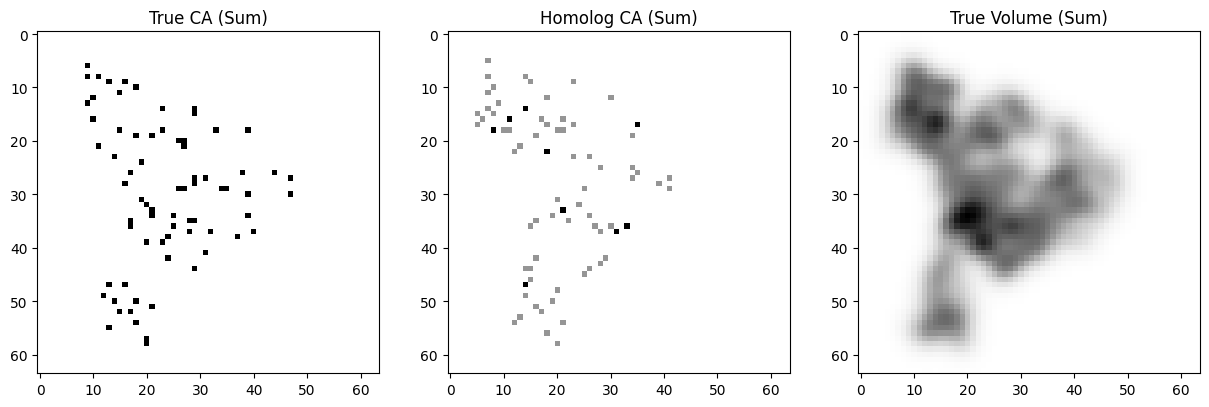

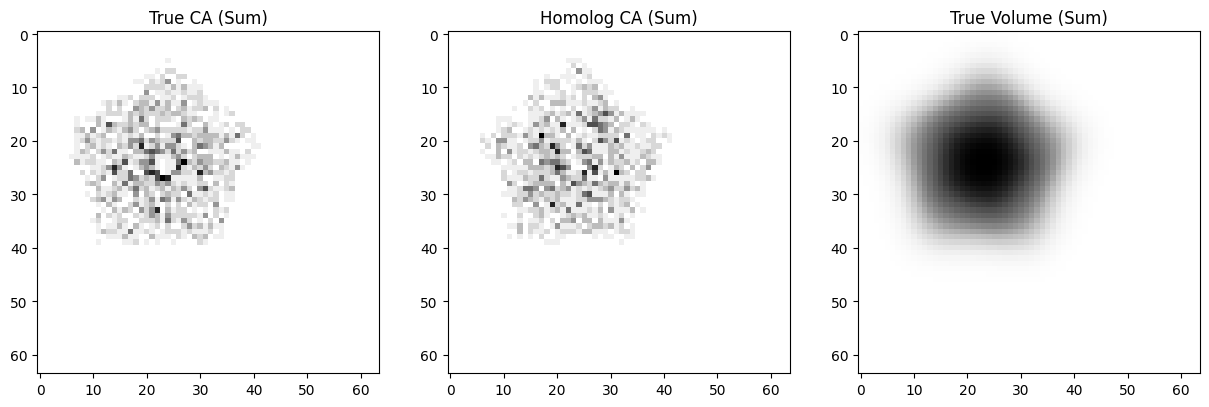

In [108]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_data(loader, num_batches=1, start_layer=0, end_layer=63):
    for i, batch in enumerate(loader):
        if i >= num_batches:
            break
        true_ca = batch['gt_voxel'].numpy()
        homolog_ca = batch['homolog_3'].numpy()
        true_vol = batch['syn_density'].numpy()

        # Take the sum over the specified range of layers
        true_ca_sum = np.sum(true_ca[:, :, :, start_layer:end_layer+1], axis=3)
        homolog_ca_sum = np.sum(homolog_ca[:, :, :, start_layer:end_layer+1], axis=3)
        true_vol_sum = np.sum(true_vol[:, :, :, start_layer:end_layer+1], axis=3)

        # Visualize the sum over layers
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))
        ax[0].imshow(true_ca_sum[0], cmap='Greys')
        ax[0].set_title('True CA (Sum)')
        ax[1].imshow(homolog_ca_sum[0], cmap='Greys')
        ax[1].set_title('Homolog CA (Sum)')
        ax[2].imshow(true_vol_sum[0], cmap='Greys')
        ax[2].set_title('True Volume (Sum)')
        plt.show()

# Visualize some data from the train loader
visualize_data(train_loader, num_batches=3)


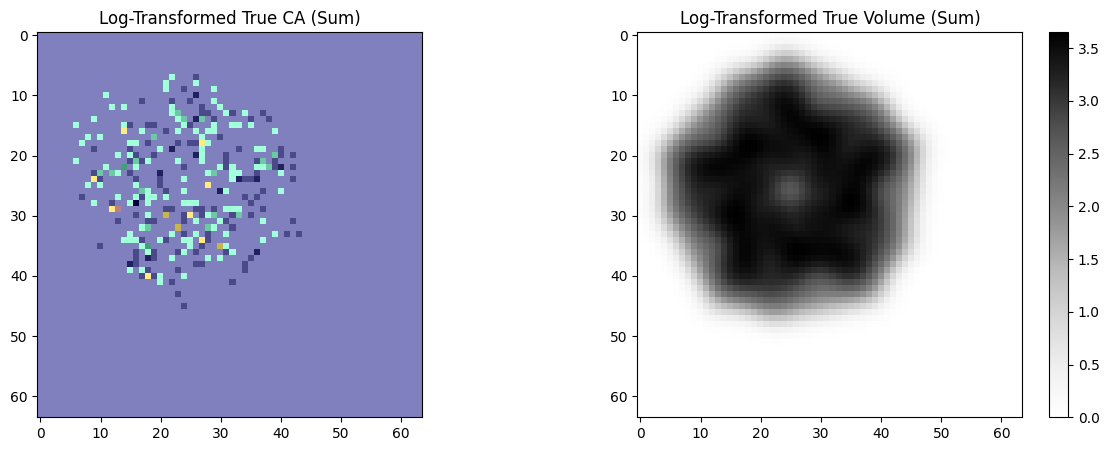

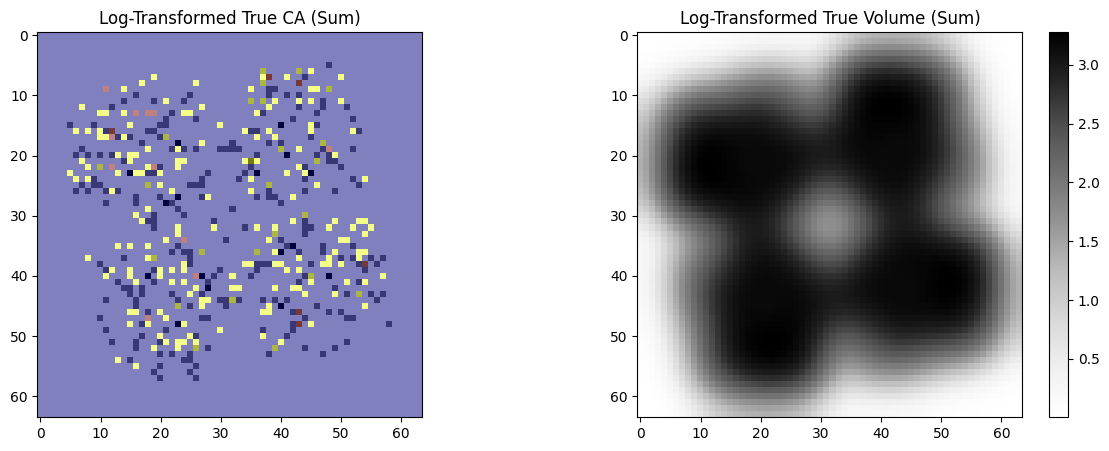

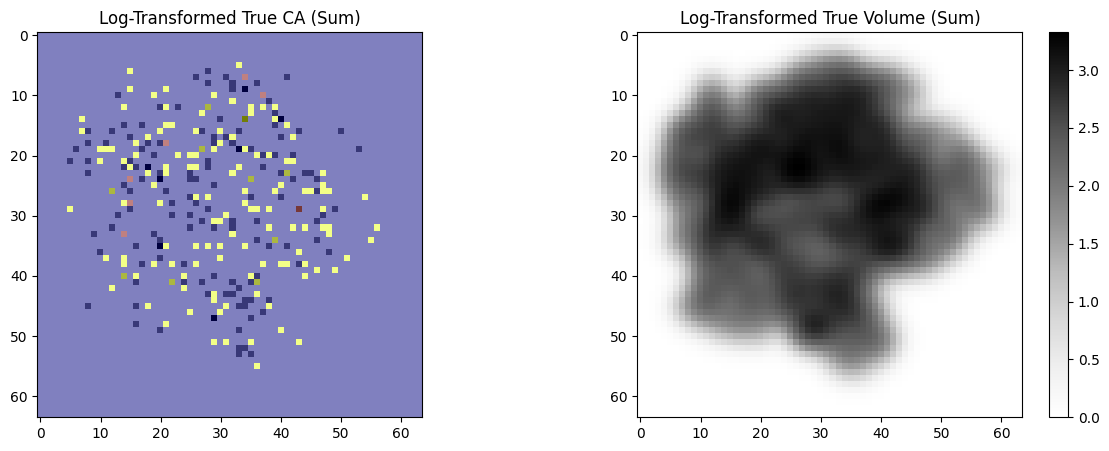

In [109]:
def visualize_data(loader, num_batches=1, start_layer=0, end_layer=63):
    for i, batch in enumerate(loader):
        if i >= num_batches:
            break
        true_ca = batch['gt_voxel'].numpy()
        homolog_ca = batch['homolog_3'].numpy()
        true_vol = batch['syn_density'].numpy()

        # Take the sum over the specified range of layers
        true_ca_sum = np.sum(true_ca[:, :, :, start_layer:end_layer+1], axis=3)
        homolog_ca_sum = np.sum(homolog_ca[:, :, :, start_layer:end_layer+1], axis=3)
        true_vol_sum = np.sum(true_vol[:, :, :, start_layer:end_layer+1], axis=3)

        # Apply logarithmic transformation to the data
        true_ca_sum_log = np.log(true_ca_sum + 1)  # Add 1 to avoid log(0)
        homolog_ca_sum_log = np.log(homolog_ca_sum + 1)  # Add 1 to avoid log(0)
        true_vol_sum_log = np.log(true_vol_sum + 1)  # Add 1 to avoid log(0)

        # Create a new figure
        fig, ax = plt.subplots(1, 2, figsize=(15, 5))

        # Visualize the log-transformed True CA (sum) with a colormap
        ax[0].imshow(true_ca_sum_log[0], cmap='Greys')
        ax[0].set_title('Log-Transformed True CA (Sum)')

        # Overlay the log-transformed Homolog CA graph on top of True CA with a different colormap
        ax[0].imshow(homolog_ca_sum_log[0], cmap='jet', alpha=0.5)

        # Visualize the log-transformed True Volume (sum)
        ax[1].imshow(true_vol_sum_log[0], cmap='Greys')
        ax[1].set_title('Log-Transformed True Volume (Sum)')

        # Add a colorbar to the plot to indicate the color mapping
        plt.colorbar(ax[1].imshow(true_vol_sum_log[0], cmap='Greys'), ax=ax[1])

        # Show the plot
        plt.show()


# Visualize some data from the train loader
visualize_data(train_loader, num_batches=3)

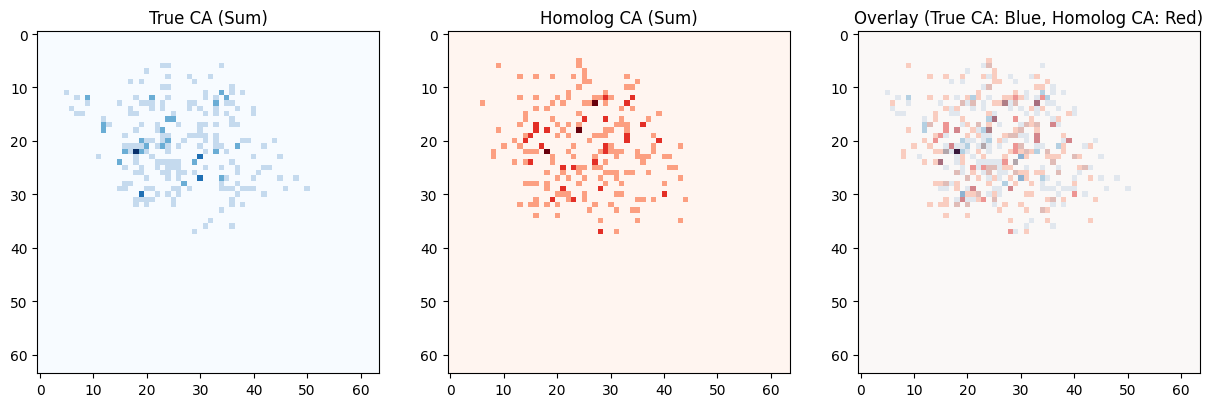

In [110]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_data(loader, num_batches=1, start_layer=0, end_layer=63):
    for i, batch in enumerate(loader):
        if i >= num_batches:
            break
        true_ca = batch['gt_voxel'].numpy()
        homolog_ca = batch['homolog_3'].numpy()
        true_vol = batch['syn_density'].numpy()

        # Take the sum over the specified range of layers
        true_ca_sum = np.sum(true_ca[:, :, :, start_layer:end_layer+1], axis=3)
        homolog_ca_sum = np.sum(homolog_ca[:, :, :, start_layer:end_layer+1], axis=3)
        true_vol_sum = np.sum(true_vol[:, :, :, start_layer:end_layer+1], axis=3)

        # Create a new figure
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))

        # Visualize True CA
        ax[0].imshow(true_ca_sum[0], cmap='Blues')
        ax[0].set_title('True CA (Sum)')

        # Visualize Homolog CA
        ax[1].imshow(homolog_ca_sum[0], cmap='Reds')
        ax[1].set_title('Homolog CA (Sum)')

        # Overlay True CA and Homolog CA
        ax[2].imshow(true_ca_sum[0], cmap='Blues')
        ax[2].imshow(homolog_ca_sum[0], cmap='Reds', alpha=0.5)
        ax[2].set_title('Overlay (True CA: Blue, Homolog CA: Red)')

        # Show the plot
        plt.show()

# Example usage
visualize_data(train_loader)


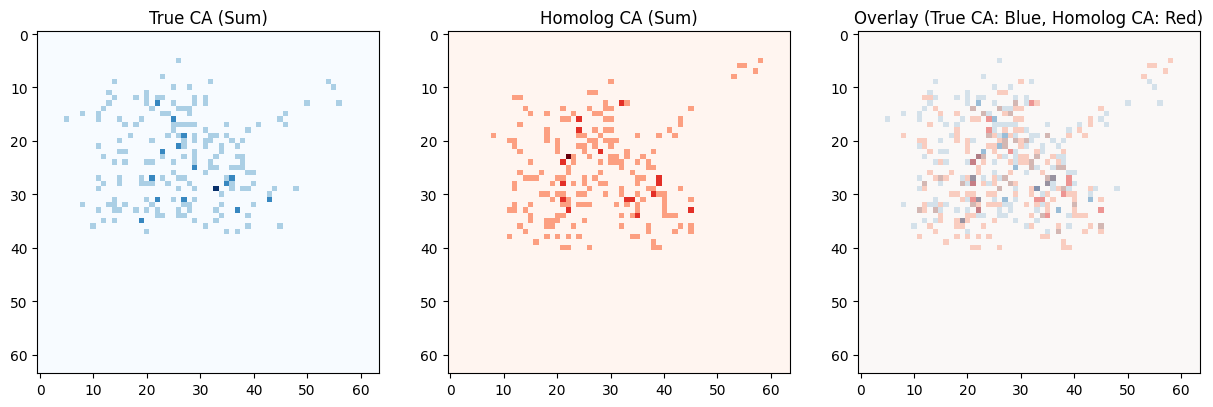

In [111]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_data(loader, num_batches=1, start_layer=0, end_layer=63):
    for i, batch in enumerate(loader):
        if i >= num_batches:
            break
        true_ca = batch['gt_voxel'].numpy()
        homolog_ca = batch['homolog_3'].numpy()
        true_vol = batch['syn_density'].numpy()

        # Take the sum over the specified range of layers
        true_ca_sum = np.sum(true_ca[:, :, :, start_layer:end_layer+1], axis=3)
        homolog_ca_sum = np.sum(homolog_ca[:, :, :, start_layer:end_layer+1], axis=3)
        true_vol_sum = np.sum(true_vol[:, :, :, start_layer:end_layer+1], axis=3)

        # Create a new figure
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))

        # Visualize True CA
        ax[0].imshow(true_ca_sum[0], cmap='Blues')
        ax[0].set_title('True CA (Sum)')

        # Visualize Homolog CA
        ax[1].imshow(homolog_ca_sum[0], cmap='Reds')
        ax[1].set_title('Homolog CA (Sum)')

        # Overlay True CA and Homolog CA
        ax[2].imshow(true_ca_sum[0], cmap='Blues')
        ax[2].imshow(homolog_ca_sum[0], cmap='Reds', alpha=0.5)
        ax[2].set_title('Overlay (True CA: Blue, Homolog CA: Red)')

        # Show the plot
        plt.show()

# Example usage
visualize_data(train_loader)


In [112]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()
        
        # Define the encoder path (downsampling)
        self.down_conv1 = self.contract_block(4, 64, 3, 1)
        self.down_conv2 = self.contract_block(64, 128, 3, 1)
        self.down_conv3 = self.contract_block(128, 256, 3, 1)
        self.down_conv4 = self.contract_block(256, 512, 3, 1)

        # Define the decoder path (upsampling)
        self.up_conv4 = self.expand_block(512, 256, 3, 1)
        self.up_conv3 = self.expand_block(256*2, 128, 3, 1)
        self.up_conv2 = self.expand_block(128*2, 64, 3, 1)
        self.up_conv1 = self.expand_block(64*2, 64, 3, 1)

        # Final output layer
        self.final_conv = nn.Conv3d(64, 1, kernel_size=3, padding=1)
        self.sigmoid = nn.Sigmoid()
        
    def __call__(self, x):
        # Encoder pathway
        x1 = self.down_conv1(x)
        x2 = self.down_conv2(F.max_pool3d(x1, kernel_size=2, stride=2))
        x3 = self.down_conv3(F.max_pool3d(x2, kernel_size=2, stride=2))
        x4 = self.down_conv4(F.max_pool3d(x3, kernel_size=2, stride=2))

        # Decoder pathway
        x = self.up_conv4(F.interpolate(x4, scale_factor=2))
        x = self.up_conv3(F.interpolate(torch.cat((x, x3), 1), scale_factor=2))
        x = self.up_conv2(F.interpolate(torch.cat((x, x2), 1), scale_factor=2))
        x = self.up_conv1(F.interpolate(torch.cat((x, x1), 1), scale_factor=2))

        # Final output
        x = self.final_conv(x)
        x = self.sigmoid(x)
        return x

    def contract_block(self, in_channels, out_channels, kernel_size, padding):
        contract = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=kernel_size, padding=padding),
            nn.ReLU(inplace=True),
            nn.BatchNorm3d(out_channels),
            nn.Conv3d(out_channels, out_channels, kernel_size=kernel_size, padding=padding),
            nn.ReLU(inplace=True),
            nn.BatchNorm3d(out_channels)
        )
        return contract

    def expand_block(self, in_channels, out_channels, kernel_size, padding):
        expand = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=kernel_size, padding=padding),
            nn.ReLU(inplace=True),
            nn.BatchNorm3d(out_channels),
            nn.Conv3d(out_channels, out_channels, kernel_size=kernel_size, padding=padding),
            nn.ReLU(inplace=True),
            nn.BatchNorm3d(out_channels)
        )
        return expand

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

model = UNet().to(device)

Using device: cuda


In [116]:
!pip install torchsummary
from torchsummary import summary

# Print the model summary
summary(model, (4, 64, 64, 64))  

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv3d-1       [-1, 64, 64, 64, 64]           6,976
              ReLU-2       [-1, 64, 64, 64, 64]               0
       BatchNorm3d-3       [-1, 64, 64, 64, 64]             128
            Conv3d-4       [-1, 64, 64, 64, 64]         110,656
              ReLU-5       [-1, 64, 64, 64, 64]               0
       BatchNorm3d-6       [-1, 64, 64, 64, 64]             128
            Conv3d-7      [-1, 128, 32, 32, 32]         221,312
              ReLU-8      [-1, 128, 32, 32, 32]               0
       BatchNorm3d-9      [-1, 128, 32, 32, 32]             256
           Conv3d-10      [-1, 128, 32, 32, 32]         442,496
             ReLU-11      [-1, 128, 32, 32, 32]               0
      BatchNorm3d-12      [-1, 128, 32, 32, 32]             256
           Conv3d-13      [-1,

In [117]:
import numpy as np

def calculate_rmsd(array1, array2):
    """
    Calculate the Root Mean Square Deviation (RMSD) between two 3D arrays.
    
    Parameters:
        array1 (numpy.ndarray): First 3D binary array.
        array2 (numpy.ndarray): Second 3D binary array.
        
    Returns:
        float: The RMSD value.
    """
    # Ensure the arrays have the same shape
    assert array1.shape == array2.shape, "Arrays must have the same shape"
    
    # Flatten the arrays to 1D
    flat_array1 = array1.flatten()
    flat_array2 = array2.flatten()
    
    # Calculate the sum of squared differences
    squared_diff = np.sum((flat_array1 - flat_array2) ** 2)
    
    # Calculate the mean squared difference
    mean_squared_diff = squared_diff / len(flat_array1)
    
    # Calculate the RMSD
    rmsd = np.sqrt(mean_squared_diff)
    
    return rmsd


In [ ]:
num_epochs = 1
print(f"Number of Epochs to Run: {num_epochs}")

model = UNet().to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
for epoch in range(num_epochs):
    model.train()
    for i, batch in enumerate(train_loader):
        homolog_1 = batch['homolog_1'].to(device)
        homolog_2 = batch['homolog_2'].to(device)
        homolog_3 = batch['homolog_3'].to(device)
        true_vol = batch['true_vol'].to(device)
        true_ca = batch['true_ca'].to(device)

        # Concatenate homolog_ca and true_vol as model input
        #inputs = torch.cat((homolog_ca.unsqueeze(1), true_vol.unsqueeze(1)), dim=1)
        #print(f"Input shape: {inputs.shape}")

        # Stack the arrays along a new dimension to create a tensor of shape 2x64x64x64
        inputs = torch.stack((homolog_1, homolog_2, homolog_3, true_vol), dim=1)
        #print(f"Input shape: {inputs.shape}")
        
        optimizer.zero_grad()
        outputs = model(inputs)

        # Compute the predictions corresponding to the homolog_ca array
        homolog_ca_predictions = outputs[:, :1, :, :, :]  # Assuming the predictions are in the first channel

        # Compute the loss
        #loss = criterion(homolog_ca_predictions, homolog_ca.unsqueeze(1))  # Assuming homolog_ca has a channel dimension
        loss = criterion(homolog_ca_predictions, true_ca.unsqueeze(1))
        #loss = criterion(outputs, true_ca)
        loss.backward()
        optimizer.step()

        # Log the training loss
        print(f"Epoch {epoch+1}/{num_epochs}, Step {i+1}/{len(train_loader)}, Loss: {loss.item()}")


Number of Epochs to Run: 1


KeyError: 'homolog_ca'

26


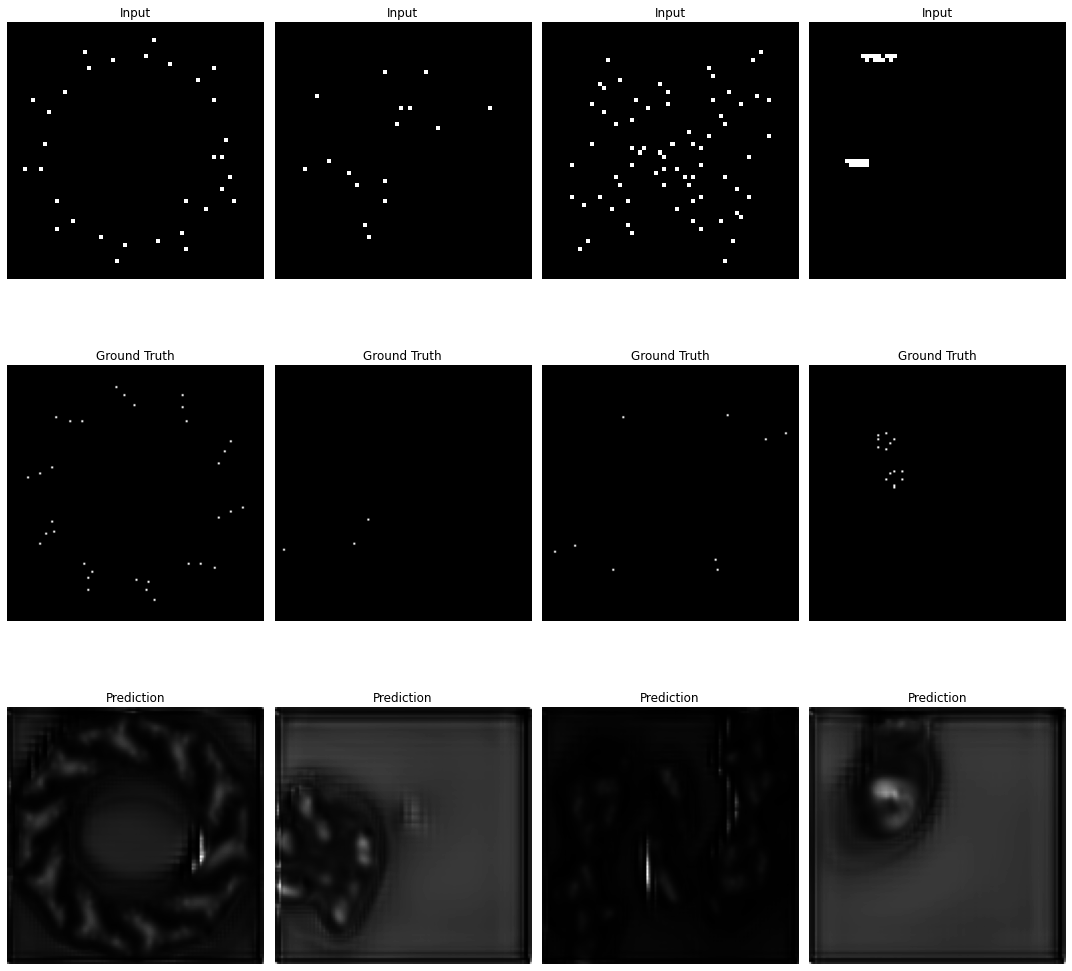

'\ndef plot_slices_with_sum(inputs_array, ground_truth_array, predictions_array, start_layer=0, end_layer=63):\n    fig, ax = plt.subplots(3, 4, figsize=(16, 12))\n\n    for i, (input, gt, preds) in enumerate(zip(inputs_array, ground_truth_array, predictions_array)):\n        \n        # Check array shapes\n        print("Input shape:", input.shape)\n        print("Ground truth shape:", gt.shape)\n        print("Prediction shape:", preds.shape)\n\n        # Perform summation along the depth axis\n        input_sum = np.sum(input[:, :, :, start_layer:end_layer], axis=3)\n        true_sum = np.sum(gt[:, :, start_layer:end_layer], axis=3)\n        pred_sum = np.sum(preds[:, :, start_layer:end_layer], axis=3)\n\n        # Plot the summed slices\n        ax[0, i].imshow(input_sum[0], cmap=\'gray\')\n        ax[0, i].set_title(\'Input Sum\')\n        ax[0, i].axis(\'off\')\n\n        ax[1, i].imshow(true_sum[0], cmap=\'gray\')\n        ax[1, i].set_title(\'Ground Truth Sum\')\n        ax[1, 

In [75]:
# Set the model to evaluation mode
model.eval()

# Initialize lists to store inputs, ground truth, and predictions
inputs_list = []
predictions_list = []
ground_truth_list = []

# Iterate over the test data
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        homolog_ca = batch['homolog_ca'].to(device)
        true_vol = batch['true_vol'].to(device)
        true_ca = batch['true_ca'].to(device)

        inputs = torch.stack((homolog_ca, true_vol), dim=1)
        
        # Forward pass
        outputs = model(inputs)

        # Append inputs, ground truth, and predictions to the lists
        inputs_list.append(inputs.cpu().numpy())
        predictions_list.append(outputs.cpu().numpy())
        ground_truth_list.append(true_ca.cpu().numpy())

# Convert lists to NumPy arrays
inputs_array = np.concatenate(inputs_list, axis=0)
predictions_array = np.concatenate(predictions_list, axis=0)
ground_truth_array = np.concatenate(ground_truth_list, axis=0)

length = len(ground_truth_array)
print(length)

# Visualize the input data, ground truth, and predictions
# Example visualization code (modify as needed)
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(15,15))

for i in range(4):
    axes[0, i].imshow(inputs_array[i, 0, :, :, 32], cmap='gray')  # Show the input slice
    axes[0, i].set_title('Input')
    axes[0, i].axis('off')

    axes[1, i].imshow(ground_truth_array[i, :, :, 32], cmap='gray')  # Show the ground truth slice
    axes[1, i].set_title('Ground Truth')
    axes[1, i].axis('off')

    axes[2, i].imshow(predictions_array[i, 0, :, :, 32], cmap='gray')  # Show the prediction slice
    axes[2, i].set_title('Prediction')
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

import numpy as np
import matplotlib.pyplot as plt

'''
def plot_slices_with_sum(inputs_array, ground_truth_array, predictions_array, start_layer=0, end_layer=63):
    fig, ax = plt.subplots(3, 4, figsize=(16, 12))

    for i, (input, gt, preds) in enumerate(zip(inputs_array, ground_truth_array, predictions_array)):
        
        # Check array shapes
        print("Input shape:", input.shape)
        print("Ground truth shape:", gt.shape)
        print("Prediction shape:", preds.shape)

        # Perform summation along the depth axis
        input_sum = np.sum(input[:, :, :, start_layer:end_layer], axis=3)
        true_sum = np.sum(gt[:, :, start_layer:end_layer], axis=3)
        pred_sum = np.sum(preds[:, :, start_layer:end_layer], axis=3)

        # Plot the summed slices
        ax[0, i].imshow(input_sum[0], cmap='gray')
        ax[0, i].set_title('Input Sum')
        ax[0, i].axis('off')

        ax[1, i].imshow(true_sum[0], cmap='gray')
        ax[1, i].set_title('Ground Truth Sum')
        ax[1, i].axis('off')

        ax[2, i].imshow(pred_sum[0], cmap='gray')
        ax[2, i].set_title('Prediction Sum')
        ax[2, i].axis('off')

    plt.show()

# Example usage
plot_slices_with_sum(inputs_array, ground_truth_array, predictions_array)
'''

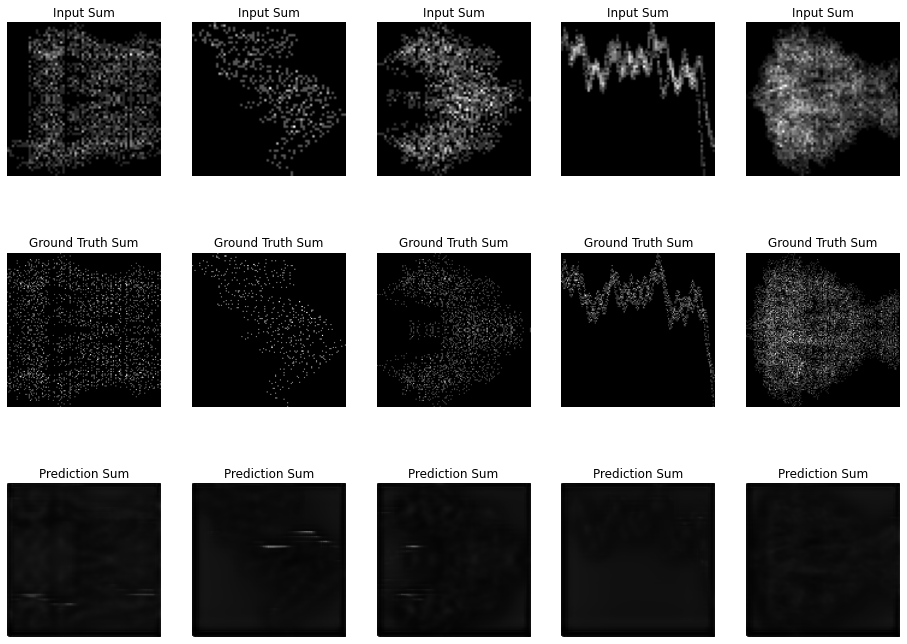

In [76]:
import numpy as np
import matplotlib.pyplot as plt

def plot_slices_with_sum(inputs_array, ground_truth_array, predictions_array, start_layer=0, end_layer=63):
    fig, ax = plt.subplots(3, 5, figsize=(16, 12))

    for i, (input, gt, preds) in enumerate(zip(inputs_array, ground_truth_array, predictions_array)):    
        
        # Perform summation along the depth axis
        input_sum = np.sum(input[0], axis=0)
        true_sum = np.sum(gt, axis=0)
        pred_sum = np.sum(np.sum(preds, axis=0), axis=0)

        # Plot the summed slices
        ax[0, i].imshow(input_sum, cmap='gray')  # Select a slice along the depth axis
        ax[0, i].set_title('Input Sum')
        ax[0, i].axis('off')

        ax[1, i].imshow(true_sum, cmap='gray')  # Select a slice along the depth axis
        ax[1, i].set_title('Ground Truth Sum')
        ax[1, i].axis('off')

        ax[2, i].imshow(pred_sum, cmap='gray')  # Select a slice along the depth axis
        ax[2, i].set_title('Prediction Sum')
        ax[2, i].axis('off')
   
        if i == 4:
            break

    plt.show()
    
# Example usage
plot_slices_with_sum(inputs_array, ground_truth_array, predictions_array)
